# 注意力评分函数 (Attention Scoring Functions)

参考: https://zh-v2.d2l.ai/chapter_attention-mechanisms/attention-scoring-functions.html

In [1]:
import math
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

## 1. 掩蔽 Softmax 操作

In [2]:
def sequence_mask(X, valid_len, value=0):
    """在序列中屏蔽不相关的项"""
    maxlen = X.size(1)
    mask = torch.arange((maxlen), dtype=torch.float32,
                        device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

def masked_softmax(X, valid_lens):
    """通过在最后一个轴上掩蔽元素来执行softmax操作"""
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [3]:
# 示例1: 有效长度为 [2, 3]
result = masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))
print("示例1 - 有效长度为 [2, 3]:")
print(result)

示例1 - 有效长度为 [2, 3]:
tensor([[[0.6380, 0.3620, 0.0000, 0.0000],
         [0.4645, 0.5355, 0.0000, 0.0000]],

        [[0.2325, 0.3129, 0.4546, 0.0000],
         [0.3567, 0.2066, 0.4367, 0.0000]]])


In [4]:
# 示例2: 每行有不同的有效长度
result = masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))
print("示例2 - 每行有不同的有效长度 [[1, 3], [2, 4]]:")
print(result)

示例2 - 每行有不同的有效长度 [[1, 3], [2, 4]]:
tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.3051, 0.3950, 0.2999, 0.0000]],

        [[0.4121, 0.5879, 0.0000, 0.0000],
         [0.1477, 0.2929, 0.2446, 0.3148]]])


## 2. 加性注意力 (Additive Attention)

In [5]:
class AdditiveAttention(nn.Module):
    """加性注意力"""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [6]:
queries, keys = torch.normal(0, 1, (2, 1, 20)), torch.ones((2, 10, 2))
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(2, 1, 1)
valid_lens = torch.tensor([2, 6])

attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8, dropout=0.1)
attention.eval()
output = attention(queries, keys, values, valid_lens)
print("加性注意力输出:")
print(output)

加性注意力输出:
tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]], grad_fn=<BmmBackward0>)


In [7]:
def show_heatmaps(matrices, xlabel='Keys', ylabel='Queries', figsize=(6, 2.5), cmap='Reds'):
    """显示注意力权重热力图"""
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    # 使用 constrained_layout 替代 tight_layout，避免与 colorbar 冲突
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, 
                             sharex=True, sharey=True, squeeze=False,
                             constrained_layout=True)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
    fig.colorbar(pcm, ax=axes, shrink=0.6)
    plt.show()

加性注意力权重热力图:


/tmp/ipykernel_8573/2432661376.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


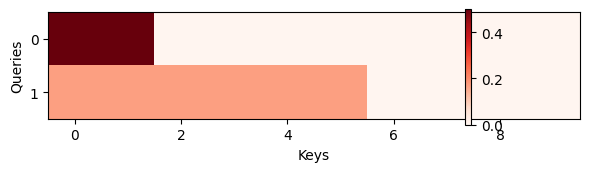

In [8]:
print("加性注意力权重热力图:")
show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)))

## 3. 缩放点积注意力 (Scaled Dot-Product Attention)

In [9]:
class DotProductAttention(nn.Module):
    """缩放点积注意力"""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [10]:
queries = torch.normal(0, 1, (2, 1, 2))
dot_attention = DotProductAttention(dropout=0.5)
dot_attention.eval()
output = dot_attention(queries, keys, values, valid_lens)
print("缩放点积注意力输出:")
print(output)

缩放点积注意力输出:
tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]])


缩放点积注意力权重热力图:


/tmp/ipykernel_8573/2432661376.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


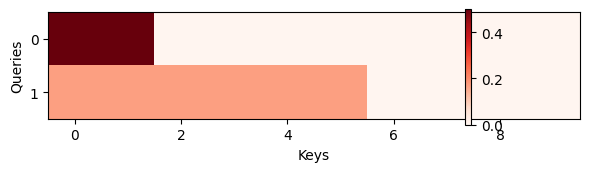

In [11]:
print("缩放点积注意力权重热力图:")
show_heatmaps(dot_attention.attention_weights.reshape((1, 1, 2, 10)))

## 4. 对比: 使用不同的键

使用不同键的缩放点积注意力权重热力图:


/tmp/ipykernel_8573/2432661376.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


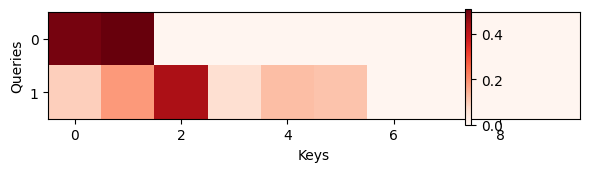

In [12]:
keys_varied = torch.randn((2, 10, 2))
queries_varied = torch.randn((2, 1, 2))

dot_attention_varied = DotProductAttention(dropout=0.0)
dot_attention_varied.eval()
output_varied = dot_attention_varied(queries_varied, keys_varied, values, valid_lens)

print("使用不同键的缩放点积注意力权重热力图:")
show_heatmaps(dot_attention_varied.attention_weights.reshape((1, 1, 2, 10)))

## 5. 小结

- 注意力汇聚的输出是值的加权平均
- 当查询和键长度不同时，使用**加性注意力**
- 当查询和键长度相同时，使用**缩放点积注意力**效率更高